# Amazon Musical Instruments Recommendation System - Data Loading & EDA

Graph Neural Network Based Recommendation System Project

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import gzip

# import matplotlib
# matplotlib.use("Agg", force=True)

import matplotlib.pyplot as plt
# print(matplotlib.get_backend())

import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import defaultdict
import scipy.sparse as sp

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Libraries imported successfully!")

PyTorch version: 2.9.1+cu130
CUDA available: True
Using device: cuda
Libraries imported successfully!


---

## 2. Data Loading

### 2.1 Load Ratings Data

In [2]:
# Load ratings data
ratings_df = pd.read_csv('data/ratings_Musical_Instruments.csv', 
                         names=['user_id', 'item_id', 'rating', 'timestamp'])

print(f"Ratings data shape: {ratings_df.shape}")
print(f"\nFirst 5 rows:")
display(ratings_df.head())

Ratings data shape: (500176, 4)

First 5 rows:


,user_id,item_id,rating,timestamp
0,A1YS9MDZP93857,0006428320,3.0,1394496000
1,A3TS466QBAWB9D,0014072149,5.0,1370476800
2,A3BUDYITWUSIS7,0041291905,5.0,1381708800
3,A19K10Z0D2NTZK,0041913574,5.0,1285200000
4,A14X336IB4JD89,0201891859,1.0,1350432000


### 2.2 Load Reviews Data

In [3]:
# Load reviews data
def load_json_gz(file_path):
    """Load compressed JSON file (handles both JSON and Python dict format)"""
    import ast
    data = []
    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                # Try standard JSON first
                data.append(json.loads(line))
            except json.JSONDecodeError:
                # If that fails, try using ast.literal_eval for Python dict format
                try:
                    data.append(ast.literal_eval(line))
                except:
                    # Skip malformed lines
                    print(f"Warning: Skipping malformed line: {line[:50]}...")
                    continue
    return pd.DataFrame(data)

reviews_df = load_json_gz('data/reviews_Musical_Instruments.json.gz')

print(f"Reviews data shape: {reviews_df.shape}")
print(f"\nColumn names: {reviews_df.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(reviews_df.head(3))

Reviews data shape: (500176, 9)

Column names: ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime']

First 3 rows:


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A1YS9MDZP93857,0006428320,John Taylor,"[0, 0]",The portfolio is fine except for the fact that...,3.0,Parts missing,1394496000,"03 11, 2014"
1,A3TS466QBAWB9D,0014072149,Silver Pencil,"[0, 0]",If you are a serious violin student on a budge...,5.0,"Perform it with a friend, today!",1370476800,"06 6, 2013"
2,A3BUDYITWUSIS7,0041291905,joyce gabriel cornett,"[0, 0]",This is and excellent edition and perfectly tr...,5.0,Vivalldi's Four Seasons,1381708800,"10 14, 2013"


### 2.3 Load Product Metadata

In [4]:
# Load product metadata
meta_df = load_json_gz('data/meta_Musical_Instruments.json.gz')

print(f"Metadata shape: {meta_df.shape}")
print(f"\nColumn names: {meta_df.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(meta_df.head(3))

Metadata shape: (84901, 9)

Column names: ['asin', 'title', 'price', 'imUrl', 'salesRank', 'categories', 'related', 'brand', 'description']

First 3 rows:


,asin,title,price,imUrl,salesRank,categories,related,brand,description
0,0006428320,"Six Sonatas For Two Flutes Or Violins, Volume ...",17.95,http://ecx.images-amazon.com/images/I/41EpRmh8...,{'Musical Instruments': 207315},"[[Musical Instruments, Instrument Accessories,...",NaN,NaN,NaN
1,0014072149,Double Concerto in D Minor By Johann Sebastian...,18.77,http://ecx.images-amazon.com/images/I/41m6ygCq...,{'Musical Instruments': 94593},[[Musical Instruments]],"{'also_viewed': ['B0058DK7RA'], 'buy_after_vie...",,Composer: J.S. Bach.Peters Edition.For two vio...
2,0041291905,Hal Leonard Vivaldi Four Seasons for Piano (Or...,NaN,http://ecx.images-amazon.com/images/I/41maAqSO...,{'Musical Instruments': 222972},"[[Musical Instruments, Instrument Accessories,...",NaN,NaN,Vivaldi's famous set of four violin concertos ...


---

## 3. Basic Data Statistics

### 3.1 Ratings Data Statistics

In [5]:
print("=" * 60)
print("Ratings Data Basic Statistics")
print("=" * 60)

print(f"\nTotal interactions: {len(ratings_df):,}")
print(f"Unique users: {ratings_df['user_id'].nunique():,}")
print(f"Unique items: {ratings_df['item_id'].nunique():,}")
print(f"Data sparsity: {(1 - len(ratings_df) / (ratings_df['user_id'].nunique() * ratings_df['item_id'].nunique())) * 100:.4f}%")

print(f"\nRating statistics:")
print(ratings_df['rating'].describe())

print(f"\nData types:")
print(ratings_df.dtypes)

print(f"\nMissing values:")
print(ratings_df.isnull().sum())

Ratings Data Basic Statistics

Total interactions: 500,176
Unique users: 339,231
Unique items: 83,046
Data sparsity: 99.9982%

Rating statistics:
count    500176.000000
mean          4.244350
std           1.203374
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64

Data types:
user_id       object
item_id       object
rating       float64
timestamp      int64
dtype: object

Missing values:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64


### 3.2 Reviews Data Statistics

In [6]:
print("=" * 60)
print("Reviews Data Basic Statistics")
print("=" * 60)

print(f"\nTotal reviews: {len(reviews_df):,}")
print(f"\nData types:")
print(reviews_df.dtypes)

print(f"\nMissing values statistics:")
missing_stats = reviews_df.isnull().sum()
missing_pct = (missing_stats / len(reviews_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_stats,
    'Missing Percentage (%)': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

Reviews Data Basic Statistics

Total reviews: 500,176

Data types:
reviewerID         object
asin               object
reviewerName       object
helpful            object
reviewText         object
overall           float64
summary            object
unixReviewTime      int64
reviewTime         object
dtype: object

Missing values statistics:
              Missing Count  Missing Percentage (%)
reviewerName           2586                    0.52


### 3.3 Product Metadata Statistics

In [7]:
print("=" * 60)
print("Product Metadata Basic Statistics")
print("=" * 60)

print(f"\nTotal products: {len(meta_df):,}")
print(f"\nData types:")
print(meta_df.dtypes)

print(f"\nMissing values statistics:")
missing_stats = meta_df.isnull().sum()
missing_pct = (missing_stats / len(meta_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_stats,
    'Missing Percentage (%)': missing_pct
})
print(missing_df)

Product Metadata Basic Statistics

Total products: 84,901

Data types:
asin            object
title           object
price          float64
imUrl           object
salesRank       object
categories      object
related         object
brand           object
description     object
dtype: object

Missing values statistics:
             Missing Count  Missing Percentage (%)
asin                     0                    0.00
title                 9665                   11.38
price                15831                   18.65
imUrl                   69                    0.08
salesRank             2368                    2.79
categories               0                    0.00
related              16558                   19.50
brand                50387                   59.35
description           6272                    7.39


### 3.4 Data Quality Analysis

#### 3.4.1 Missing Values Analysis

MISSING VALUES ANALYSIS

1. RATINGS DATA:
----------------------------------------
✓ No missing values found in ratings data

2. REVIEWS DATA:
----------------------------------------
              Missing Count  Percentage (%)
reviewerName           2586            0.52

3. METADATA:
----------------------------------------
             Missing Count  Percentage (%)
title                 9665           11.38
price                15831           18.65
imUrl                   69            0.08
salesRank             2368            2.79
related              16558           19.50
brand                50387           59.35
description           6272            7.39


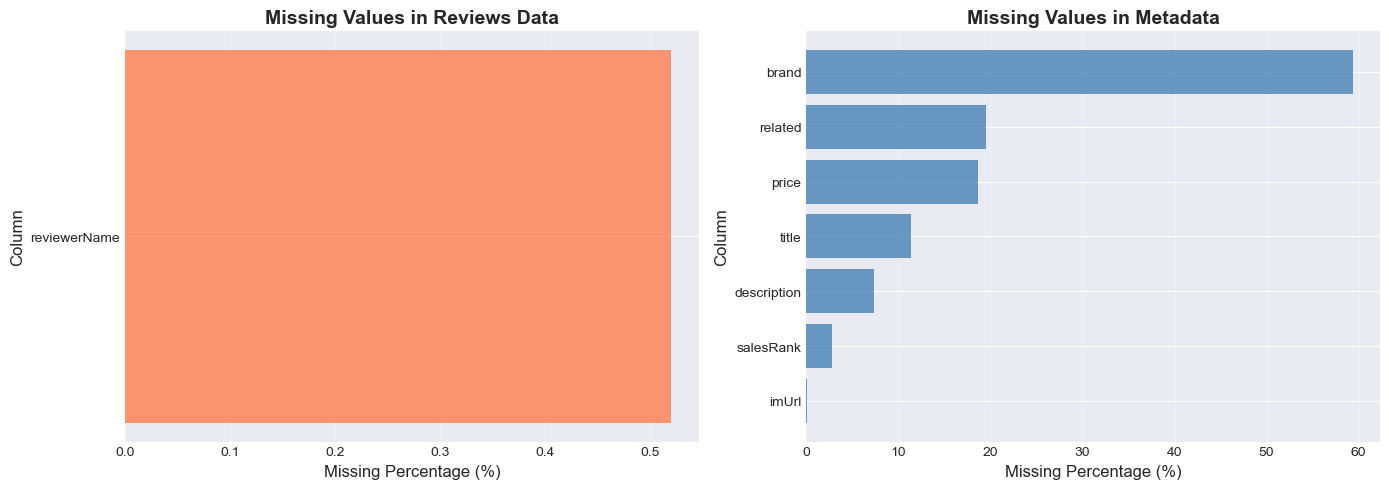

In [8]:
# Comprehensive missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

print("\n1. RATINGS DATA:")
print("-" * 40)
ratings_missing = ratings_df.isnull().sum()
if ratings_missing.sum() == 0:
    print("✓ No missing values found in ratings data")
else:
    print(ratings_missing[ratings_missing > 0])

print("\n2. REVIEWS DATA:")
print("-" * 40)
reviews_missing = reviews_df.isnull().sum()
reviews_missing_pct = (reviews_missing / len(reviews_df) * 100).round(2)
reviews_missing_summary = pd.DataFrame({
    'Missing Count': reviews_missing,
    'Percentage (%)': reviews_missing_pct
})
print(reviews_missing_summary[reviews_missing_summary['Missing Count'] > 0])

print("\n3. METADATA:")
print("-" * 40)
meta_missing = meta_df.isnull().sum()
meta_missing_pct = (meta_missing / len(meta_df) * 100).round(2)
meta_missing_summary = pd.DataFrame({
    'Missing Count': meta_missing,
    'Percentage (%)': meta_missing_pct
})
print(meta_missing_summary[meta_missing_summary['Missing Count'] > 0])

# # Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reviews missing values
reviews_missing_plot = reviews_missing_summary[reviews_missing_summary['Missing Count'] > 0].sort_values('Percentage (%)', ascending=True)
if len(reviews_missing_plot) > 0:
    axes[0].barh(reviews_missing_plot.index, reviews_missing_plot['Percentage (%)'], color='coral', alpha=0.8)
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12)
    axes[0].set_ylabel('Column', fontsize=12)
    axes[0].set_title('Missing Values in Reviews Data', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values in Reviews Data', fontsize=14, fontweight='bold')

# Metadata missing values
meta_missing_plot = meta_missing_summary[meta_missing_summary['Missing Count'] > 0].sort_values('Percentage (%)', ascending=True)
if len(meta_missing_plot) > 0:
    axes[1].barh(meta_missing_plot.index, meta_missing_plot['Percentage (%)'], color='steelblue', alpha=0.8)
    axes[1].set_xlabel('Missing Percentage (%)', fontsize=12)
    axes[1].set_ylabel('Column', fontsize=12)
    axes[1].set_title('Missing Values in Metadata', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=14)
    axes[1].set_title('Missing Values in Metadata', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.4.2 Duplicate Values Analysis

DUPLICATE VALUES ANALYSIS

1. RATINGS DATA:
----------------------------------------
Exact duplicate rows: 0 (0.00%)
Duplicate user-item pairs: 0 (0.00%)
Duplicate user-item-rating combinations: 0 (0.00%)

2. REVIEWS DATA:
----------------------------------------
Exact duplicate rows (hashable columns only): 0 (0.00%)
Duplicate reviewer-product pairs: 0 (0.00%)

3. METADATA:
----------------------------------------
Exact duplicate rows (hashable columns only): 0 (0.00%)
Duplicate ASINs: 0 (0.00%)


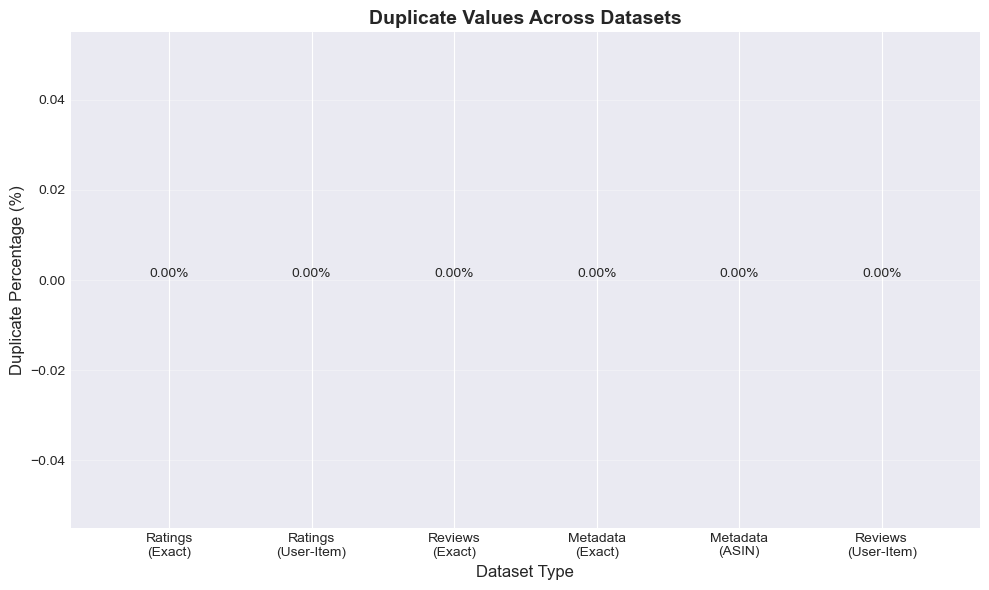

In [9]:
# Comprehensive duplicate values analysis
print("=" * 80)
print("DUPLICATE VALUES ANALYSIS")
print("=" * 80)

print("\n1. RATINGS DATA:")
print("-" * 40)
# Check for exact duplicates
ratings_exact_dup = ratings_df.duplicated().sum()
print(f"Exact duplicate rows: {ratings_exact_dup:,} ({ratings_exact_dup/len(ratings_df)*100:.2f}%)")

# Check for duplicate user-item pairs
ratings_user_item_dup = ratings_df.duplicated(subset=['user_id', 'item_id']).sum()
print(f"Duplicate user-item pairs: {ratings_user_item_dup:,} ({ratings_user_item_dup/len(ratings_df)*100:.2f}%)")

# Check for duplicate user-item-rating combinations
ratings_user_item_rating_dup = ratings_df.duplicated(subset=['user_id', 'item_id', 'rating']).sum()
print(f"Duplicate user-item-rating combinations: {ratings_user_item_rating_dup:,} ({ratings_user_item_rating_dup/len(ratings_df)*100:.2f}%)")

# Show examples if duplicates exist
if ratings_user_item_dup > 0:
    print("\nExample of duplicate user-item pairs:")
    dup_mask = ratings_df.duplicated(subset=['user_id', 'item_id'], keep=False)
    dup_examples = ratings_df[dup_mask].sort_values(['user_id', 'item_id']).head(10)
    print(dup_examples)

print("\n2. REVIEWS DATA:")
print("-" * 40)
# Only check hashable columns (exclude lists, dicts, etc.)
hashable_cols = []
for col in reviews_df.columns:
    try:
        # Try to hash the first non-null value
        sample = reviews_df[col].dropna().iloc[0] if len(reviews_df[col].dropna()) > 0 else None
        if sample is not None:
            hash(sample)
        hashable_cols.append(col)
    except (TypeError, AttributeError):
        # Skip unhashable columns
        pass

if len(hashable_cols) > 0:
    reviews_exact_dup = reviews_df[hashable_cols].duplicated().sum()
    print(f"Exact duplicate rows (hashable columns only): {reviews_exact_dup:,} ({reviews_exact_dup/len(reviews_df)*100:.2f}%)")
else:
    reviews_exact_dup = 0
    print("Cannot check for exact duplicates (no hashable columns)")

# Check for duplicate reviewerID-asin pairs if columns exist
if 'reviewerID' in reviews_df.columns and 'asin' in reviews_df.columns:
    reviews_user_item_dup = reviews_df.duplicated(subset=['reviewerID', 'asin']).sum()
    print(f"Duplicate reviewer-product pairs: {reviews_user_item_dup:,} ({reviews_user_item_dup/len(reviews_df)*100:.2f}%)")
    
    if reviews_user_item_dup > 0:
        print("\nExample of duplicate reviewer-product pairs:")
        dup_mask = reviews_df.duplicated(subset=['reviewerID', 'asin'], keep=False)
        dup_examples = reviews_df[dup_mask].sort_values(['reviewerID', 'asin'])[['reviewerID', 'asin', 'overall']].head(10)
        print(dup_examples)
else:
    reviews_user_item_dup = 0

print("\n3. METADATA:")
print("-" * 40)
# Only check hashable columns for metadata
meta_hashable_cols = []
for col in meta_df.columns:
    try:
        sample = meta_df[col].dropna().iloc[0] if len(meta_df[col].dropna()) > 0 else None
        if sample is not None:
            hash(sample)
        meta_hashable_cols.append(col)
    except (TypeError, AttributeError):
        pass

if len(meta_hashable_cols) > 0:
    meta_exact_dup = meta_df[meta_hashable_cols].duplicated().sum()
    print(f"Exact duplicate rows (hashable columns only): {meta_exact_dup:,} ({meta_exact_dup/len(meta_df)*100:.2f}%)")
else:
    meta_exact_dup = 0
    print("Cannot check for exact duplicates (no hashable columns)")

# Check for duplicate ASINs
if 'asin' in meta_df.columns:
    meta_asin_dup = meta_df.duplicated(subset=['asin']).sum()
    print(f"Duplicate ASINs: {meta_asin_dup:,} ({meta_asin_dup/len(meta_df)*100:.2f}%)")
    
    if meta_asin_dup > 0:
        print("\nExample of duplicate ASINs:")
        dup_mask = meta_df.duplicated(subset=['asin'], keep=False)
        dup_examples = meta_df[dup_mask].sort_values('asin')[['asin', 'title', 'brand']].head(10)
        print(dup_examples)
else:
    meta_asin_dup = 0

# Visualize duplicates
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

duplicate_summary = {
    'Ratings\n(Exact)': ratings_exact_dup / len(ratings_df) * 100,
    'Ratings\n(User-Item)': ratings_user_item_dup / len(ratings_df) * 100,
    'Reviews\n(Exact)': reviews_exact_dup / len(reviews_df) * 100,
    'Metadata\n(Exact)': meta_exact_dup / len(meta_df) * 100
}

if 'asin' in meta_df.columns:
    duplicate_summary['Metadata\n(ASIN)'] = meta_asin_dup / len(meta_df) * 100

if 'reviewerID' in reviews_df.columns and 'asin' in reviews_df.columns:
    duplicate_summary['Reviews\n(User-Item)'] = reviews_user_item_dup / len(reviews_df) * 100

categories = list(duplicate_summary.keys())
values = list(duplicate_summary.values())

bars = ax.bar(categories, values, color=['steelblue', 'coral', 'green', 'orange', 'purple'][:len(categories)], alpha=0.8)
ax.set_ylabel('Duplicate Percentage (%)', fontsize=12)
ax.set_xlabel('Dataset Type', fontsize=12)
ax.set_title('Duplicate Values Across Datasets', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---

## 4. Exploratory Data Analysis (EDA)

### 4.1 Rating Distribution

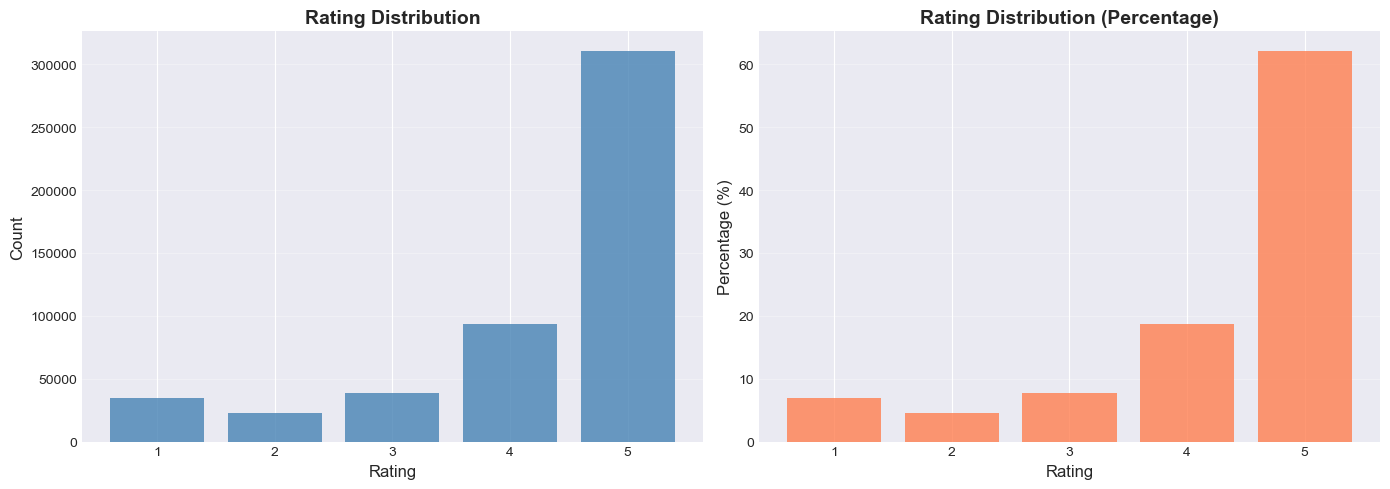


Rating distribution:
         Count  Percentage (%)
rating                        
1.0      34931            6.98
2.0      22618            4.52
3.0      38537            7.70
4.0      93306           18.65
5.0     310784           62.13


In [10]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
rating_counts = ratings_df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Percentage plot
rating_pct = (rating_counts / len(ratings_df) * 100).round(2)
axes[1].bar(rating_pct.index, rating_pct.values, color='coral', alpha=0.8)
axes[1].set_xlabel('Rating', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Rating Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRating distribution:")
print(pd.DataFrame({'Count': rating_counts, 'Percentage (%)': rating_pct}))

### 4.2 User Activity Analysis

User Activity Statistics:
Mean interactions per user: 1.47
Median interactions per user: 1.00
Max interactions per user: 483
Min interactions per user: 1


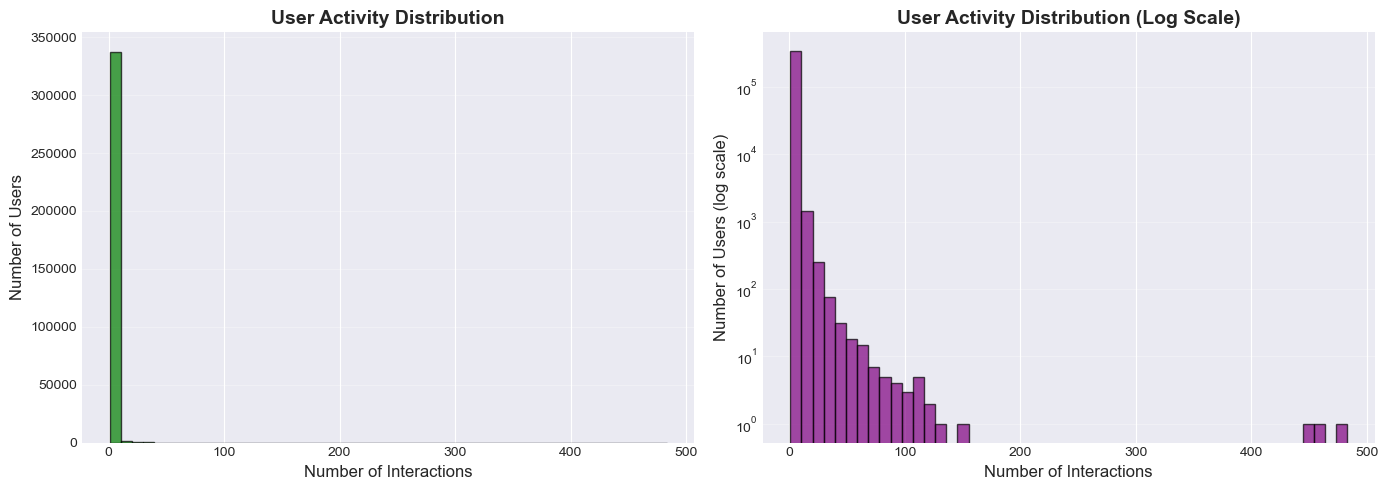


Top 10 most active users:
user_id
A2PAD826IH1HFE    483
A2AIMXT9PLAM12    463
A2NYK9KWFMJV4Y    454
A33GGROUQRQZS     154
A2PR6NXG0PA3KY    135
ALAJL3S09HBS7     126
AGLHCU1KX96DZ     118
A21VR7M8O55EF6    114
A16CZRQL23NOIW    113
A1F89OE7BAM7EL    110
dtype: int64


In [11]:
# User activity statistics
user_activity = ratings_df.groupby('user_id').size()

print("User Activity Statistics:")
print(f"Mean interactions per user: {user_activity.mean():.2f}")
print(f"Median interactions per user: {user_activity.median():.2f}")
print(f"Max interactions per user: {user_activity.max()}")
print(f"Min interactions per user: {user_activity.min()}")

# Visualize user activity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(user_activity, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Number of Interactions', fontsize=12)
axes[0].set_ylabel('Number of Users', fontsize=12)
axes[0].set_title('User Activity Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Log scale histogram
axes[1].hist(user_activity, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Number of Interactions', fontsize=12)
axes[1].set_ylabel('Number of Users (log scale)', fontsize=12)
axes[1].set_title('User Activity Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Top active users
print("\nTop 10 most active users:")
print(user_activity.sort_values(ascending=False).head(10))

### 4.3 Item Popularity Analysis

Item Popularity Statistics:
Mean interactions per item: 6.02
Median interactions per item: 2.00
Max interactions per item: 3523
Min interactions per item: 1


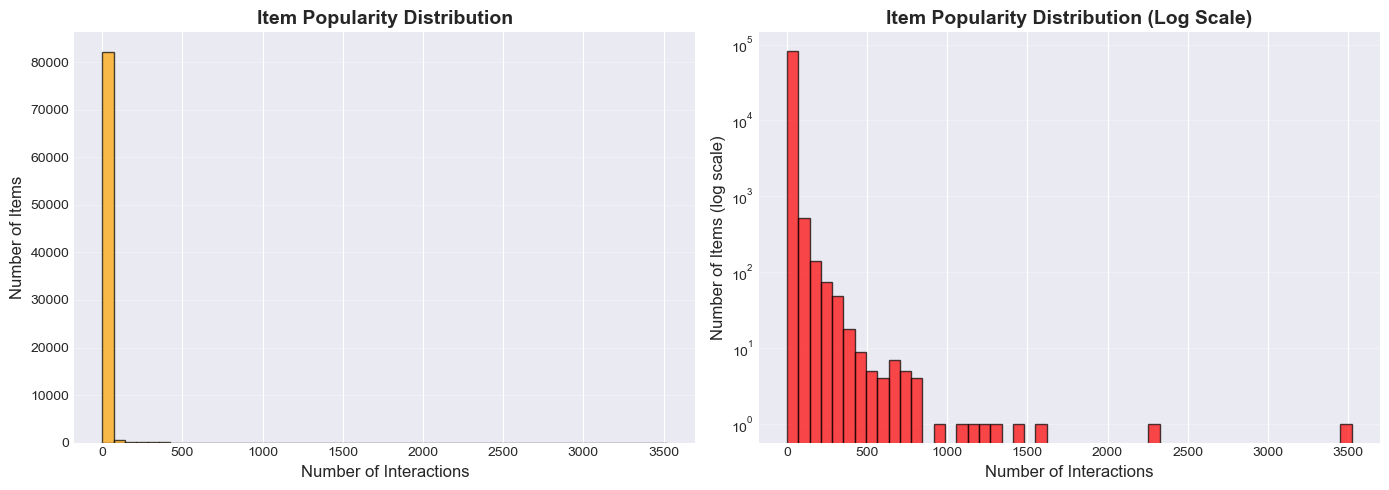


Top 10 most popular items:
item_id
B000ULAP4U    3523
B003VWJ2K8    2275
B003VWKPHC    1603
B001MSS6CS    1420
B00FPPQYXM    1287
1417030321    1218
B009E3EWPI    1192
B002VA464S    1066
B002024UDE     942
B00063678K     817
dtype: int64


In [12]:
# Item popularity statistics
item_popularity = ratings_df.groupby('item_id').size()

print("Item Popularity Statistics:")
print(f"Mean interactions per item: {item_popularity.mean():.2f}")
print(f"Median interactions per item: {item_popularity.median():.2f}")
print(f"Max interactions per item: {item_popularity.max()}")
print(f"Min interactions per item: {item_popularity.min()}")

# Visualize item popularity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(item_popularity, bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Number of Interactions', fontsize=12)
axes[0].set_ylabel('Number of Items', fontsize=12)
axes[0].set_title('Item Popularity Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Log scale histogram
axes[1].hist(item_popularity, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Number of Interactions', fontsize=12)
axes[1].set_ylabel('Number of Items (log scale)', fontsize=12)
axes[1].set_title('Item Popularity Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Top popular items
print("\nTop 10 most popular items:")
print(item_popularity.sort_values(ascending=False).head(10))

### 4.4 Temporal Analysis

Temporal Statistics:
Date range: 1998-04-25 00:00:00 to 2014-07-23 00:00:00
Time span: 5933 days


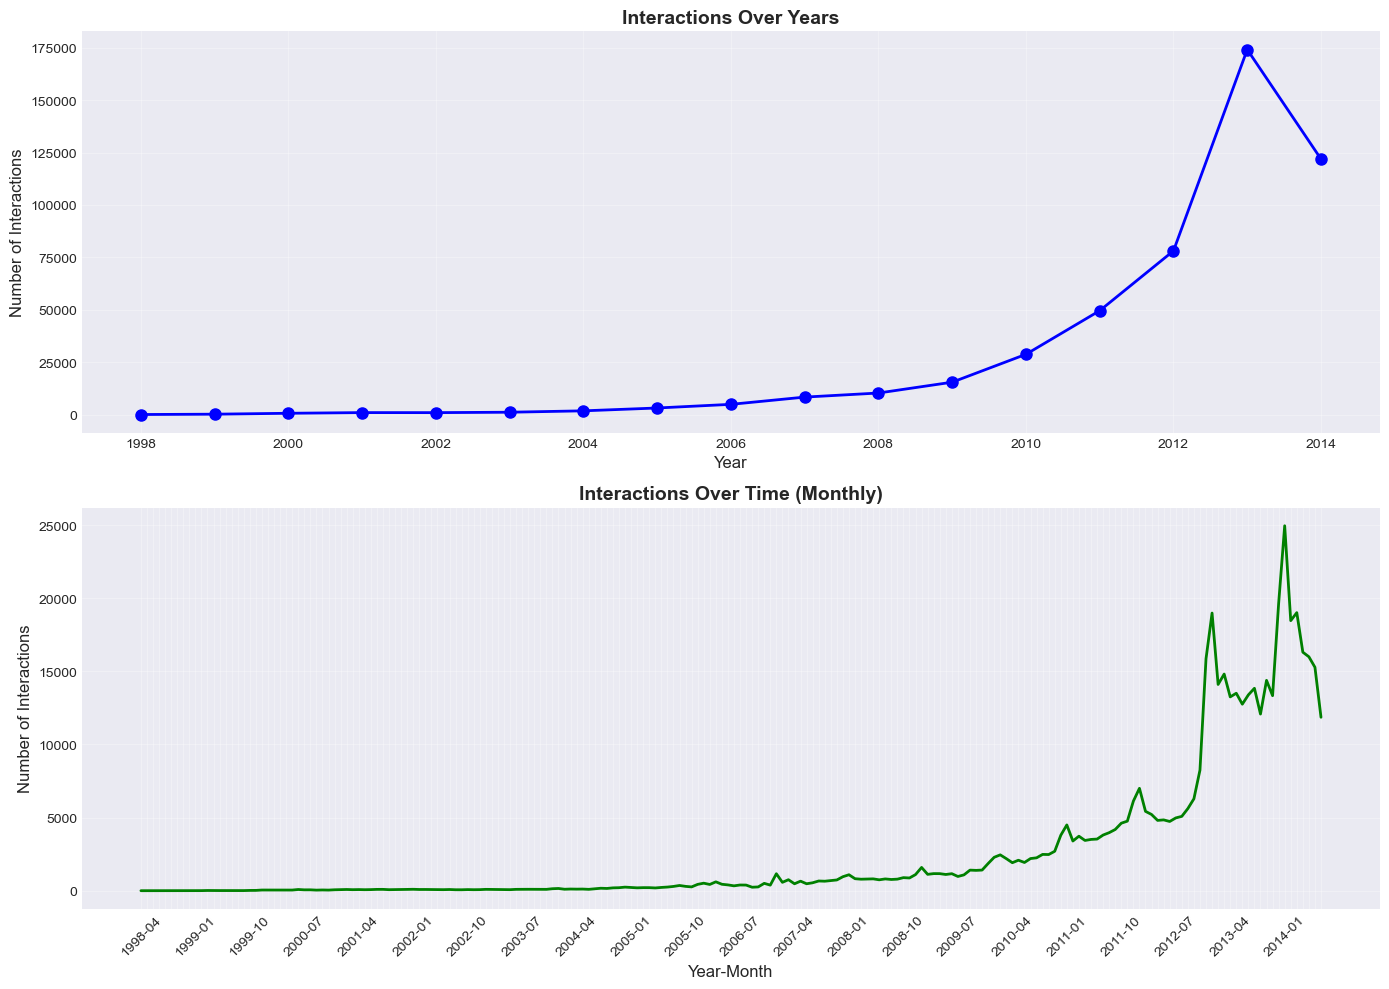

In [13]:
# Convert timestamp to datetime
ratings_df['datetime'] = pd.to_datetime(ratings_df['timestamp'], unit='s')
ratings_df['year'] = ratings_df['datetime'].dt.year
ratings_df['month'] = ratings_df['datetime'].dt.month
ratings_df['year_month'] = ratings_df['datetime'].dt.to_period('M')

print("Temporal Statistics:")
print(f"Date range: {ratings_df['datetime'].min()} to {ratings_df['datetime'].max()}")
print(f"Time span: {(ratings_df['datetime'].max() - ratings_df['datetime'].min()).days} days")

# Interactions over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# By year
yearly_counts = ratings_df['year'].value_counts().sort_index()
axes[0].plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Interactions', fontsize=12)
axes[0].set_title('Interactions Over Years', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# By month (aggregated)
monthly_counts = ratings_df.groupby('year_month').size()
axes[1].plot(monthly_counts.index.astype(str), monthly_counts.values, linewidth=2, color='green')
axes[1].set_xlabel('Year-Month', fontsize=12)
axes[1].set_ylabel('Number of Interactions', fontsize=12)
axes[1].set_title('Interactions Over Time (Monthly)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Show only every nth label to avoid crowding
n = max(1, len(monthly_counts) // 20)
for i, label in enumerate(axes[1].xaxis.get_ticklabels()):
    if i % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

### 4.5 Reviews Text Analysis

Review Text Statistics:
Mean review length (characters): 482.14
Mean review word count: 87.91
Median review length (characters): 263.00
Median review word count: 49.00


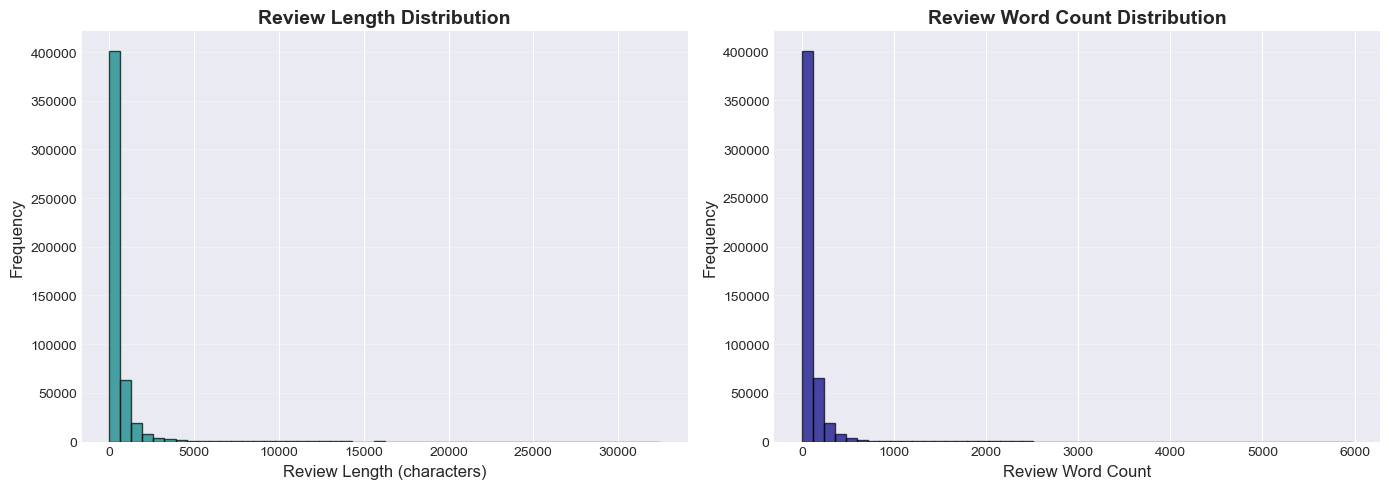

In [14]:
# Review text length analysis
if 'reviewText' in reviews_df.columns:
    reviews_df['review_length'] = reviews_df['reviewText'].fillna('').apply(len)
    reviews_df['review_word_count'] = reviews_df['reviewText'].fillna('').apply(lambda x: len(x.split()))
    
    print("Review Text Statistics:")
    print(f"Mean review length (characters): {reviews_df['review_length'].mean():.2f}")
    print(f"Mean review word count: {reviews_df['review_word_count'].mean():.2f}")
    print(f"Median review length (characters): {reviews_df['review_length'].median():.2f}")
    print(f"Median review word count: {reviews_df['review_word_count'].median():.2f}")
    
    # Visualize review length distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(reviews_df['review_length'], bins=50, color='teal', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Review Length (characters)', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    axes[1].hist(reviews_df['review_word_count'], bins=50, color='navy', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Review Word Count', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Review Word Count Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No reviewText column found in reviews data")

### 4.6 Product Categories Analysis

Total unique categories: 1114

Top 15 categories:
                         Category  Count
0             Musical Instruments  85478
1          Instrument Accessories  42724
2                     CDs & Vinyl  39093
3             General Accessories  18291
4       Guitar & Bass Accessories  12688
5                       Classical   9390
6                             Pop   9096
7                         Guitars   6509
8              Live Sound & Stage   5654
9             Sheet Music Folders   4906
10             Drums & Percussion   4897
11     Studio Recording Equipment   4879
12                   Folk & World   4761
13                           Rock   4386
14  Drum & Percussion Accessories   4036


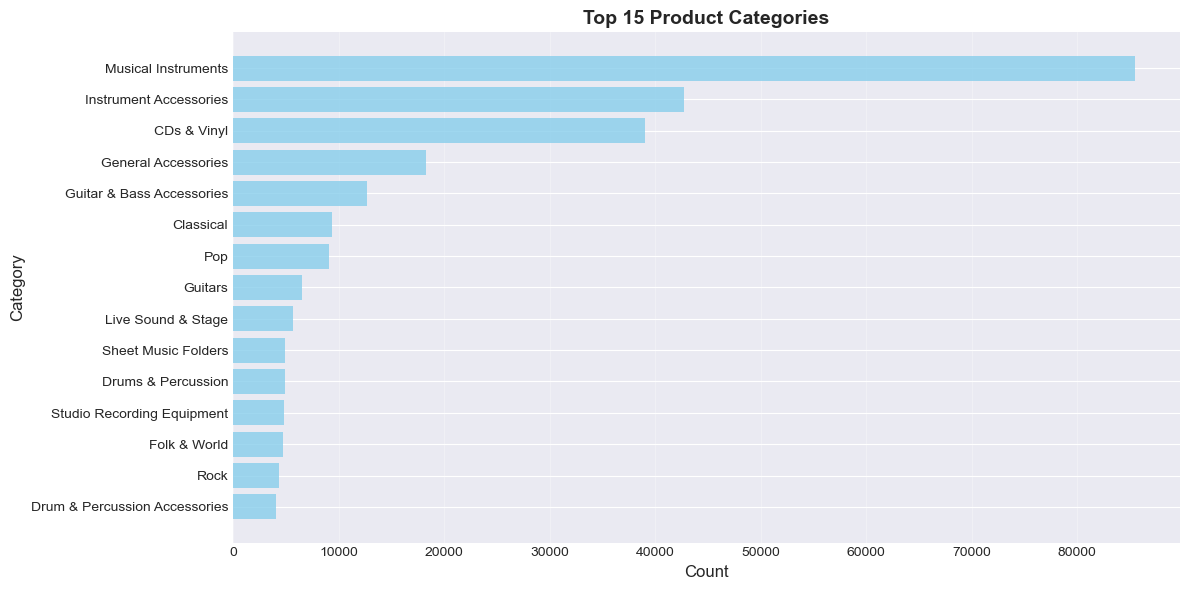

In [15]:
# Analyze product categories
if 'categories' in meta_df.columns:
    # Extract all categories
    all_categories = []
    for cats in meta_df['categories'].dropna():
        if isinstance(cats, list):
            for cat_list in cats:
                if isinstance(cat_list, list):
                    all_categories.extend(cat_list)
    
    category_counts = Counter(all_categories)
    
    print(f"Total unique categories: {len(category_counts)}")
    print("\nTop 15 categories:")
    top_categories = pd.DataFrame(category_counts.most_common(15), 
                                  columns=['Category', 'Count'])
    print(top_categories)
    
    # Visualize top categories
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(top_categories)), top_categories['Count'], color='skyblue', alpha=0.8)
    plt.yticks(range(len(top_categories)), top_categories['Category'])
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Category', fontsize=12)
    plt.title('Top 15 Product Categories', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No categories column found in metadata")

---

## 5. Data Summary

In [16]:
print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

summary = {
    'Metric': [
        'Total Interactions',
        'Unique Users',
        'Unique Items',
        'Data Sparsity (%)',
        'Avg Interactions per User',
        'Avg Interactions per Item',
        'Rating Range',
        'Most Common Rating',
        'Total Reviews',
        'Total Products in Metadata'
    ],
    'Value': [
        f"{len(ratings_df):,}",
        f"{ratings_df['user_id'].nunique():,}",
        f"{ratings_df['item_id'].nunique():,}",
        f"{(1 - len(ratings_df) / (ratings_df['user_id'].nunique() * ratings_df['item_id'].nunique())) * 100:.4f}",
        f"{user_activity.mean():.2f}",
        f"{item_popularity.mean():.2f}",
        f"{ratings_df['rating'].min()} - {ratings_df['rating'].max()}",
        f"{ratings_df['rating'].mode()[0]}",
        f"{len(reviews_df):,}",
        f"{len(meta_df):,}"
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print("=" * 80)

DATASET SUMMARY
                    Metric     Value
        Total Interactions   500,176
              Unique Users   339,231
              Unique Items    83,046
         Data Sparsity (%)   99.9982
 Avg Interactions per User      1.47
 Avg Interactions per Item      6.02
              Rating Range 1.0 - 5.0
        Most Common Rating       5.0
             Total Reviews   500,176
Total Products in Metadata    84,901


---

---

# PART 2: MODEL IMPLEMENTATION

## 6. Data Preprocessing for Models

### 6.1 Import Libraries and Setup

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import defaultdict
import scipy.sparse as sp

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.9.1+cu130
CUDA available: True
Using device: cuda


### 6.2 Data Filtering and Splitting

In [18]:
# Filter users and items with minimum interactions (k-core filtering)
def filter_kcore(df, k=5):
    """Filter users and items with at least k interactions"""
    print(f"\nApplying {k}-core filtering...")
    print(f"Original: {len(df)} interactions, {df['user_id'].nunique()} users, {df['item_id'].nunique()} items")
    
    while True:
        user_counts = df['user_id'].value_counts()
        item_counts = df['item_id'].value_counts()
        
        valid_users = user_counts[user_counts >= k].index
        valid_items = item_counts[item_counts >= k].index
        
        df_filtered = df[df['user_id'].isin(valid_users) & df['item_id'].isin(valid_items)]
        
        if len(df_filtered) == len(df):
            break
        df = df_filtered
    
    print(f"After filtering: {len(df)} interactions, {df['user_id'].nunique()} users, {df['item_id'].nunique()} items")
    return df

# Apply k-core filtering
# Try different k values to find the best balance
print("\nTrying different k values:")
print("-" * 60)

for k in [2, 3, 4, 5]:
    temp_df = filter_kcore(ratings_df.copy(), k=k)
    sparsity = (1 - len(temp_df) / (temp_df['user_id'].nunique() * temp_df['item_id'].nunique())) * 100
    print(f"k={k}: {len(temp_df):,} interactions, {temp_df['user_id'].nunique():,} users, {temp_df['item_id'].nunique():,} items, sparsity: {sparsity:.2f}%")

# Use k=3 for better data size (balance between quality and quantity)
print("\nUsing k=3 for final filtering...")
ratings_filtered = filter_kcore(ratings_df.copy(), k=3)


Trying different k values:
------------------------------------------------------------

Applying 2-core filtering...
Original: 500176 interactions, 339231 users, 83046 items
After filtering: 184556 interactions, 57202 users, 25717 items
k=2: 184,556 interactions, 57,202 users, 25,717 items, sparsity: 99.99%

Applying 3-core filtering...
Original: 500176 interactions, 339231 users, 83046 items
After filtering: 82855 interactions, 17500 users, 9237 items
k=3: 82,855 interactions, 17,500 users, 9,237 items, sparsity: 99.95%

Applying 4-core filtering...
Original: 500176 interactions, 339231 users, 83046 items
After filtering: 35012 interactions, 5839 users, 3340 items
k=4: 35,012 interactions, 5,839 users, 3,340 items, sparsity: 99.82%

Applying 5-core filtering...
Original: 500176 interactions, 339231 users, 83046 items
After filtering: 10261 interactions, 1429 users, 900 items
k=5: 10,261 interactions, 1,429 users, 900 items, sparsity: 99.20%

Using k=3 for final filtering...

Applyin

In [19]:
# Create user and item ID mappings
unique_users = ratings_filtered['user_id'].unique()
unique_items = ratings_filtered['item_id'].unique()

user2id = {user: idx for idx, user in enumerate(unique_users)}
item2id = {item: idx for idx, item in enumerate(unique_items)}
id2user = {idx: user for user, idx in user2id.items()}
id2item = {idx: item for item, idx in item2id.items()}

# Map to integer IDs
ratings_filtered['user_idx'] = ratings_filtered['user_id'].map(user2id)
ratings_filtered['item_idx'] = ratings_filtered['item_id'].map(item2id)

n_users = len(user2id)
n_items = len(item2id)

print(f"\nNumber of users: {n_users}")
print(f"Number of items: {n_items}")
print(f"Number of interactions: {len(ratings_filtered)}")
print(f"Sparsity: {(1 - len(ratings_filtered) / (n_users * n_items)) * 100:.4f}%")


Number of users: 17500
Number of items: 9237
Number of interactions: 82855
Sparsity: 99.9487%


In [20]:
ratings_filtered.head()

,user_id,item_id,rating,timestamp,datetime,year,month,year_month,user_idx,item_idx
24,A1D1S69ZMKYCCV,0634061801,5.0,1289001600,2010-11-06,2010,11,2010-11,0,0
26,A3T7SXCKJUYXT3,0634061801,5.0,1190851200,2007-09-27,2007,9,2007-09,1,0
31,A3DM7ADJV144TZ,0634061801,4.0,1365811200,2013-04-13,2013,4,2013-04,2,0
68,AFA6HGI3MW3SA,0739040375,5.0,1173744000,2007-03-13,2007,3,2007-03,3,1
69,A1FPATLQSFTLC9,0739040375,5.0,1335916800,2012-05-02,2012,5,2012-05,4,1


In [21]:
# Temporal split: use last interaction per user as test set
def temporal_split(df):
    """Split data temporally: last interactions for test"""
    df_sorted = df.sort_values('timestamp')
    
    # Group by user and take last interactions as test
    test_data = df_sorted.groupby('user_idx').tail(1)
    train_data = df_sorted[~df_sorted.index.isin(test_data.index)]
    
    # Further split train into train and validation
    train_users = train_data.groupby('user_idx')
    val_data = train_users.tail(1)
    train_data = train_data[~train_data.index.isin(val_data.index)]
    
    return train_data, val_data, test_data

train_data, val_data, test_data = temporal_split(ratings_filtered)

print(f"\nData split:")
print(f"Train: {len(train_data)} interactions")
print(f"Validation: {len(val_data)} interactions")
print(f"Test: {len(test_data)} interactions")


Data split:
Train: 47855 interactions
Validation: 17500 interactions
Test: 17500 interactions


### 6.3 Build User-Item Bipartite Graph

In [22]:
def build_bipartite_graph(train_df, n_users, n_items):
    """Build user-item bipartite graph adjacency matrix"""
    user_indices = train_df['user_idx'].values
    item_indices = train_df['item_idx'].values
    
    # Build adjacency matrix for bipartite graph
    row = np.concatenate([user_indices, item_indices + n_users])
    col = np.concatenate([item_indices + n_users, user_indices])
    data = np.ones(len(row))
    
    adj_mat = sp.coo_matrix((data, (row, col)), 
                            shape=(n_users + n_items, n_users + n_items))
            
    return adj_mat

# Build graph from training data
adj_mat = build_bipartite_graph(train_data, n_users, n_items)
print(f"\nBipartite graph adjacency matrix shape: {adj_mat.shape}")
print(f"Number of edges: {adj_mat.nnz // 2}")


Bipartite graph adjacency matrix shape: (26737, 26737)
Number of edges: 47855


In [23]:
def normalize_adj_matrix(adj_mat):
    """Normalize adjacency matrix: D^(-1/2) * A * D^(-1/2)"""
    adj_mat = adj_mat + sp.eye(adj_mat.shape[0])
    
    rowsum = np.array(adj_mat.sum(1))
    d_inv_sqrt = np.power(rowsum, -0.5).flatten()
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
    d_mat_inv_sqrt = sp.diags(d_inv_sqrt)
    
    norm_adj = d_mat_inv_sqrt.dot(adj_mat).dot(d_mat_inv_sqrt)
    return norm_adj.tocoo()

# Normalize adjacency matrix for GNN
norm_adj = normalize_adj_matrix(adj_mat)

# Convert to PyTorch sparse tensor
indices = torch.LongTensor([norm_adj.row, norm_adj.col])
values = torch.FloatTensor(norm_adj.data)
shape = torch.Size(norm_adj.shape)
norm_adj_tensor = torch.sparse_coo_tensor(indices, values, shape).coalesce().to(device)

print(f"Normalized adjacency matrix created")

Normalized adjacency matrix created


### 6.4 Create PyTorch Datasets

In [24]:
class RatingDataset(Dataset):
    """Dataset for rating prediction"""
    def __init__(self, data):
        self.users = torch.LongTensor(data['user_idx'].values)
        self.items = torch.LongTensor(data['item_idx'].values)
        self.ratings = torch.FloatTensor(data['rating'].values)
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

# Create datasets
train_dataset = RatingDataset(train_data)
val_dataset = RatingDataset(val_data)
test_dataset = RatingDataset(test_data)

# Create dataloaders
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created with batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


DataLoaders created with batch size: 1024
Train batches: 47
Val batches: 18
Test batches: 18


---

## 7. Baseline Model: MLP-based Two Tower

### 7.1 Model Architecture

In [25]:
class TwoTowerMLP(nn.Module):
    """MLP-based Two Tower model for recommendation"""
    def __init__(self, n_users, n_items, embedding_dim=64, hidden_dims=[128, 64]):
        super(TwoTowerMLP, self).__init__()
        
        # User and item embeddings
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)
        
        # User tower (MLP)
        user_layers = []
        input_dim = embedding_dim
        for hidden_dim in hidden_dims:
            user_layers.append(nn.Linear(input_dim, hidden_dim))
            user_layers.append(nn.ReLU())
            user_layers.append(nn.Dropout(0.2))
            input_dim = hidden_dim
        self.user_tower = nn.Sequential(*user_layers)
        
        # Item tower (MLP)
        item_layers = []
        input_dim = embedding_dim
        for hidden_dim in hidden_dims:
            item_layers.append(nn.Linear(input_dim, hidden_dim))
            item_layers.append(nn.ReLU())
            item_layers.append(nn.Dropout(0.2))
            input_dim = hidden_dim
        self.item_tower = nn.Sequential(*item_layers)
        
        # Prediction layer
        self.prediction = nn.Linear(hidden_dims[-1] * 2, 1)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)
        
        for layer in self.user_tower:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
        
        for layer in self.item_tower:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
        
        nn.init.xavier_uniform_(self.prediction.weight)
        nn.init.zeros_(self.prediction.bias)
    
    def forward(self, users, items):
        # Get embeddings
        user_emb = self.user_embedding(users)
        item_emb = self.item_embedding(items)
        
        # Pass through towers
        user_repr = self.user_tower(user_emb)
        item_repr = self.item_tower(item_emb)
        
        # Concatenate and predict
        combined = torch.cat([user_repr, item_repr], dim=1)
        rating = self.prediction(combined).squeeze()
        
        return rating

# Create model
two_tower_model = TwoTowerMLP(n_users, n_items, embedding_dim=64, hidden_dims=[128, 64]).to(device)

# Count parameters
total_params = sum(p.numel() for p in two_tower_model.parameters())
trainable_params = sum(p.numel() for p in two_tower_model.parameters() if p.requires_grad)

print(f"\nTwo Tower MLP Model:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(two_tower_model)


Two Tower MLP Model:
Total parameters: 1,744,449
Trainable parameters: 1,744,449

Model architecture:
TwoTowerMLP(
  (user_embedding): Embedding(17500, 64)
  (item_embedding): Embedding(9237, 64)
  (user_tower): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (item_tower): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (prediction): Linear(in_features=128, out_features=1, bias=True)
)


### 7.2 Training Functions

In [26]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for users, items, ratings in train_loader:
        users = users.to(device)
        items = items.to(device)
        ratings = ratings.to(device)
        
        # Forward pass
        predictions = model(users, items)
        loss = criterion(predictions, ratings)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(users)
    
    return total_loss / len(train_loader.dataset)

def evaluate(model, data_loader, device):
    """Evaluate model on validation/test set"""
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for users, items, ratings in data_loader:
            users = users.to(device)
            items = items.to(device)
            
            preds = model(users, items)
            predictions.extend(preds.cpu().numpy())
            actuals.extend(ratings.numpy())
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    # Calculate metrics
    mse = np.mean((predictions - actuals) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - actuals))
    
    return rmse, mae

print("Training functions defined")

Training functions defined


### 7.3 Train Two Tower Model

In [27]:
# Training configuration
learning_rate = 0.001
num_epochs = 20
patience = 5

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(two_tower_model.parameters(), lr=learning_rate)

# Training loop
best_val_rmse = float('inf')
patience_counter = 0
train_losses = []
val_rmses = []

print("\nTraining Two Tower MLP Model...")
print("=" * 80)

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(two_tower_model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)
    
    # Evaluate
    val_rmse, val_mae = evaluate(two_tower_model, val_loader, device)
    val_rmses.append(val_rmse)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val RMSE: {val_rmse:.4f} | Val MAE: {val_mae:.4f}")
    
    # Early stopping
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        patience_counter = 0
        # Save best model
        torch.save(two_tower_model.state_dict(), 'best_two_tower_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("\n" + "=" * 80)
print(f"Best validation RMSE: {best_val_rmse:.4f}")


Training Two Tower MLP Model...
Epoch 1/20 | Train Loss: 11.9194 | Val RMSE: 1.3549 | Val MAE: 1.0449
Epoch 2/20 | Train Loss: 1.2835 | Val RMSE: 1.0302 | Val MAE: 0.7870
Epoch 3/20 | Train Loss: 0.7617 | Val RMSE: 1.0475 | Val MAE: 0.7747
Epoch 4/20 | Train Loss: 0.6646 | Val RMSE: 1.0786 | Val MAE: 0.7920
Epoch 5/20 | Train Loss: 0.6236 | Val RMSE: 1.0987 | Val MAE: 0.8056
Epoch 6/20 | Train Loss: 0.5977 | Val RMSE: 1.1085 | Val MAE: 0.8138
Epoch 7/20 | Train Loss: 0.5778 | Val RMSE: 1.1227 | Val MAE: 0.8232

Early stopping at epoch 7

Best validation RMSE: 1.0302


In [28]:
# Load best model and evaluate on test set
two_tower_model.load_state_dict(torch.load('best_two_tower_model.pth'))
test_rmse, test_mae = evaluate(two_tower_model, test_loader, device)

print("\nTwo Tower MLP - Test Set Performance:")
print("=" * 50)
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")


Two Tower MLP - Test Set Performance:
Test RMSE: 1.0736
Test MAE: 0.8176


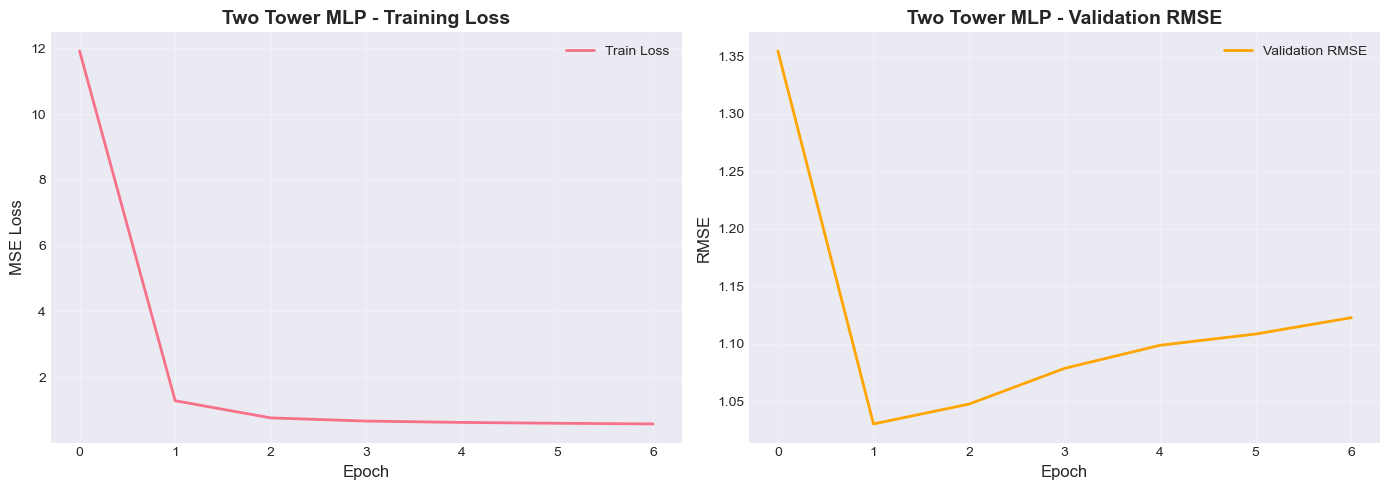

In [29]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Two Tower MLP - Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_rmses, label='Validation RMSE', color='orange', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Two Tower MLP - Validation RMSE', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 8. Graph-based Model: LightGCN

### 8.1 Model Architecture

In [30]:
class LightGCN(nn.Module):
    """LightGCN with original ranking interfaces plus an explicit-rating head."""
    def __init__(self, n_users, n_items, embedding_dim=64, n_layers=3, 
                 use_rating_bias=True, rating_range=(1.0, 5.0)):
        super(LightGCN, self).__init__()
        
        self.n_users = n_users
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers
        self.use_rating_bias = use_rating_bias
        self.rating_range = rating_range
        self.f = nn.Sigmoid()
        
        # Original LightGCN user/item embeddings
        self.embedding_user = nn.Embedding(n_users, embedding_dim)
        self.embedding_item = nn.Embedding(n_items, embedding_dim)
        
        # Optional bias terms make explicit rating prediction more flexible
        if self.use_rating_bias:
            self.user_bias = nn.Embedding(n_users, 1)
            self.item_bias = nn.Embedding(n_items, 1)
            self.global_bias = nn.Parameter(torch.zeros(1))
        
        self._init_weights()
        print(f"LightGCN initialized with {n_layers} layers")
    
    def _init_weights(self):
        nn.init.normal_(self.embedding_user.weight, std=0.1)
        nn.init.normal_(self.embedding_item.weight, std=0.1)
        
        if self.use_rating_bias:
            nn.init.zeros_(self.user_bias.weight)
            nn.init.zeros_(self.item_bias.weight)
    
    def computer(self, adj_mat):
        """Original LightGCN propagation used for ranking and rating tasks."""
        users_emb = self.embedding_user.weight
        items_emb = self.embedding_item.weight
        all_emb = torch.cat([users_emb, items_emb], dim=0)
        
        embs = [all_emb]
        for _ in range(self.n_layers):
            all_emb = torch.sparse.mm(adj_mat, all_emb)
            embs.append(all_emb)
        
        embs = torch.stack(embs, dim=1)
        light_out = torch.mean(embs, dim=1)
        users, items = torch.split(light_out, [self.n_users, self.n_items])
        return users, items
    
    def getUsersRating(self, users, adj_mat):
        """Original ranking API: sigmoid(user-item score matrix)."""
        all_users, all_items = self.computer(adj_mat)
        users_emb = all_users[users.long()]
        scores = torch.matmul(users_emb, all_items.t())
        return self.f(scores)
    
    def getEmbedding(self, users, pos_items, neg_items, adj_mat):
        """Original LightGCN helper used by BPR loss."""
        all_users, all_items = self.computer(adj_mat)
        users_emb = all_users[users.long()]
        pos_emb = all_items[pos_items.long()]
        neg_emb = all_items[neg_items.long()]
        users_emb_ego = self.embedding_user(users.long())
        pos_emb_ego = self.embedding_item(pos_items.long())
        neg_emb_ego = self.embedding_item(neg_items.long())
        return users_emb, pos_emb, neg_emb, users_emb_ego, pos_emb_ego, neg_emb_ego
    
    def bpr_loss(self, users, pos, neg, adj_mat):
        """Original LightGCN pairwise ranking loss."""
        users_emb, pos_emb, neg_emb, user_emb0, pos_emb0, neg_emb0 = self.getEmbedding(
            users, pos, neg, adj_mat
        )
        
        reg_loss = 0.5 * (
            user_emb0.norm(2).pow(2) + pos_emb0.norm(2).pow(2) + neg_emb0.norm(2).pow(2)
        ) / float(len(users))
        
        pos_scores = torch.sum(users_emb * pos_emb, dim=1)
        neg_scores = torch.sum(users_emb * neg_emb, dim=1)
        loss = torch.mean(F.softplus(neg_scores - pos_scores))
        return loss, reg_loss
    
    def _raw_scores_from_embeddings(self, users, items, user_embeddings, item_embeddings):
        users_emb = user_embeddings[users.long()]
        items_emb = item_embeddings[items.long()]
        return torch.sum(users_emb * items_emb, dim=1)
    
    def _apply_rating_head(self, raw_scores, users, items, apply_range=True):
        rating_scores = raw_scores
        
        if self.use_rating_bias:
            rating_scores = rating_scores + self.user_bias(users.long()).squeeze(-1)
            rating_scores = rating_scores + self.item_bias(items.long()).squeeze(-1)
            rating_scores = rating_scores + self.global_bias
        
        if apply_range:
            rating_min, rating_max = self.rating_range
            rating_scores = rating_min + (rating_max - rating_min) * self.f(rating_scores)
        
        return rating_scores
    
    def forward(self, users, items, adj_mat):
        """Original LightGCN forward: return raw user-item scores for ranking."""
        all_users, all_items = self.computer(adj_mat)
        return self._raw_scores_from_embeddings(users, items, all_users, all_items)
    
    def predict(self, users, items, user_embeddings=None, item_embeddings=None, 
                adj_mat=None, apply_range=True):
        """Compatibility helper for explicit rating prediction."""
        if user_embeddings is None or item_embeddings is None:
            if adj_mat is None:
                raise ValueError("adj_mat is required when embeddings are not provided")
            user_embeddings, item_embeddings = self.computer(adj_mat)
        
        raw_scores = self._raw_scores_from_embeddings(users, items, user_embeddings, item_embeddings)
        return self._apply_rating_head(raw_scores, users, items, apply_range=apply_range)
    
    def predict_rating(self, users, items, adj_mat, apply_range=True):
        return self.predict(users, items, adj_mat=adj_mat, apply_range=apply_range)

# Create LightGCN model
lightgcn_model = LightGCN(n_users, n_items, embedding_dim=64, n_layers=3).to(device)

# Count parameters
total_params = sum(p.numel() for p in lightgcn_model.parameters())
trainable_params = sum(p.numel() for p in lightgcn_model.parameters() if p.requires_grad)

print(f"\nLightGCN Model:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

LightGCN initialized with 3 layers

LightGCN Model:
Total parameters: 1,737,906
Trainable parameters: 1,737,906


### 8.2 Training Functions for LightGCN

In [31]:
def build_user_positive_items(train_df):
    """Map each user to the set of interacted items for later ranking evaluation."""
    return train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

def sample_bpr_batch(train_df, user_positive_items, num_items, batch_size):
    """Sample (user, positive item, negative item) triples for original LightGCN ranking."""
    sampled_rows = train_df.sample(n=batch_size, replace=len(train_df) < batch_size)
    users = sampled_rows['user_idx'].to_numpy(dtype=np.int64)
    pos_items = sampled_rows['item_idx'].to_numpy(dtype=np.int64)
    neg_items = []
    
    for user in users:
        positive_set = user_positive_items[user]
        neg_item = np.random.randint(num_items)
        while neg_item in positive_set:
            neg_item = np.random.randint(num_items)
        neg_items.append(neg_item)
    
    return (
        torch.LongTensor(users),
        torch.LongTensor(pos_items),
        torch.LongTensor(neg_items)
    )

def train_lightgcn_bpr_epoch(model, adj_mat, train_df, user_positive_items, num_items, 
                             optimizer, reg_weight, batch_size, device):
    """Optional ranking training loop that matches the original LightGCN objective."""
    model.train()
    total_loss = 0
    num_batches = int(np.ceil(len(train_df) / batch_size))
    
    for _ in range(num_batches):
        users, pos_items, neg_items = sample_bpr_batch(
            train_df, user_positive_items, num_items, batch_size
        )
        users = users.to(device)
        pos_items = pos_items.to(device)
        neg_items = neg_items.to(device)
        
        optimizer.zero_grad()
        bpr_loss, reg_loss = model.bpr_loss(users, pos_items, neg_items, adj_mat)
        loss = bpr_loss + reg_weight * reg_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / num_batches

def recommend_topk(model, adj_mat, users, train_user_positive_items, k=10):
    """Top-k recommendation helper for later ranking comparison."""
    model.eval()
    
    with torch.no_grad():
        users = users.long()
        scores = model.getUsersRating(users, adj_mat)
        
        for row_idx, user in enumerate(users.tolist()):
            seen_items = list(train_user_positive_items.get(user, set()))
            if seen_items:
                scores[row_idx, seen_items] = -1e9
        
        _, top_items = torch.topk(scores, k=k, dim=1)
    
    return top_items

def train_lightgcn_rating_epoch(model, adj_mat, train_loader, optimizer, reg_weight, device):
    """Train explicit rating prediction while keeping original LightGCN propagation."""
    model.train()
    total_loss = 0
    
    for users, items, ratings in train_loader:
        users = users.to(device)
        items = items.to(device)
        ratings = ratings.to(device)
        
        optimizer.zero_grad()
        predictions = model.predict_rating(users, items, adj_mat)
        mse_loss = F.mse_loss(predictions, ratings)
        
        user_emb0 = model.embedding_user(users)
        item_emb0 = model.embedding_item(items)
        reg_loss = 0.5 * (user_emb0.norm(2).pow(2) + item_emb0.norm(2).pow(2)) / len(users)
        
        if model.use_rating_bias:
            user_bias = model.user_bias(users).squeeze(-1)
            item_bias = model.item_bias(items).squeeze(-1)
            reg_loss = reg_loss + 0.5 * (
                user_bias.norm(2).pow(2) + item_bias.norm(2).pow(2)
            ) / len(users)
        
        loss = mse_loss + reg_weight * reg_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(users)
    
    return total_loss / len(train_loader.dataset)

def evaluate_lightgcn_rating(model, adj_mat, data_loader, device):
    """Evaluate explicit rating prediction with RMSE and MAE."""
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for users, items, ratings in data_loader:
            users = users.to(device)
            items = items.to(device)
            preds = model.predict_rating(users, items, adj_mat)
            predictions.extend(preds.cpu().numpy())
            actuals.extend(ratings.numpy())
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    mse = np.mean((predictions - actuals) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - actuals))
    return rmse, mae

# Backward-compatible aliases so the existing notebook training loop still runs
def train_lightgcn_epoch(model, adj_mat, train_loader, optimizer, reg_weight, device):
    return train_lightgcn_rating_epoch(model, adj_mat, train_loader, optimizer, reg_weight, device)

def evaluate_lightgcn(model, adj_mat, data_loader, device):
    return evaluate_lightgcn_rating(model, adj_mat, data_loader, device)

user_positive_items = build_user_positive_items(train_data)

print("LightGCN training functions defined")

LightGCN training functions defined


### 8.3 Train LightGCN Model

In [32]:
# Training configuration
learning_rate = 0.001
num_epochs = 20
patience = 5
reg_weight = 1e-4

# Optimizer
optimizer = torch.optim.Adam(lightgcn_model.parameters(), lr=learning_rate)

# Training loop
best_val_rmse = float('inf')
patience_counter = 0
train_losses_gcn = []
val_rmses_gcn = []

print("\nTraining LightGCN Model...")
print("=" * 80)

for epoch in range(num_epochs):
    # Train
    train_loss = train_lightgcn_epoch(lightgcn_model, norm_adj_tensor, train_loader, 
                                      optimizer, reg_weight, device)
    train_losses_gcn.append(train_loss)
    
    # Evaluate
    val_rmse, val_mae = evaluate_lightgcn(lightgcn_model, norm_adj_tensor, val_loader, device)
    val_rmses_gcn.append(val_rmse)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val RMSE: {val_rmse:.4f} | Val MAE: {val_mae:.4f}")
    
    # Early stopping
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        patience_counter = 0
        # Save best model
        torch.save(lightgcn_model.state_dict(), 'best_lightgcn_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("\n" + "=" * 80)
print(f"Best validation RMSE: {best_val_rmse:.4f}")


Training LightGCN Model...
Epoch 1/20 | Train Loss: 2.7319 | Val RMSE: 1.6658 | Val MAE: 1.5512
Epoch 2/20 | Train Loss: 2.4553 | Val RMSE: 1.6076 | Val MAE: 1.4991
Epoch 3/20 | Train Loss: 2.1576 | Val RMSE: 1.5443 | Val MAE: 1.4403
Epoch 4/20 | Train Loss: 1.8282 | Val RMSE: 1.4715 | Val MAE: 1.3684
Epoch 5/20 | Train Loss: 1.5076 | Val RMSE: 1.3982 | Val MAE: 1.2907
Epoch 6/20 | Train Loss: 1.2520 | Val RMSE: 1.3362 | Val MAE: 1.2211
Epoch 7/20 | Train Loss: 1.0732 | Val RMSE: 1.2889 | Val MAE: 1.1658
Epoch 8/20 | Train Loss: 0.9520 | Val RMSE: 1.2545 | Val MAE: 1.1244
Epoch 9/20 | Train Loss: 0.8678 | Val RMSE: 1.2300 | Val MAE: 1.0943
Epoch 10/20 | Train Loss: 0.8062 | Val RMSE: 1.2125 | Val MAE: 1.0725
Epoch 11/20 | Train Loss: 0.7586 | Val RMSE: 1.1999 | Val MAE: 1.0566
Epoch 12/20 | Train Loss: 0.7196 | Val RMSE: 1.1916 | Val MAE: 1.0459
Epoch 13/20 | Train Loss: 0.6865 | Val RMSE: 1.1860 | Val MAE: 1.0384
Epoch 14/20 | Train Loss: 0.6572 | Val RMSE: 1.1822 | Val MAE: 1.0331
E

In [33]:
# Load best model and evaluate on test set
lightgcn_model.load_state_dict(torch.load('best_lightgcn_model.pth'))
test_rmse_gcn, test_mae_gcn = evaluate_lightgcn(lightgcn_model, norm_adj_tensor, test_loader, device)

print("\nLightGCN - Test Set Performance:")
print("=" * 50)
print(f"Test RMSE: {test_rmse_gcn:.4f}")
print(f"Test MAE: {test_mae_gcn:.4f}")


LightGCN - Test Set Performance:
Test RMSE: 1.2095
Test MAE: 1.0554


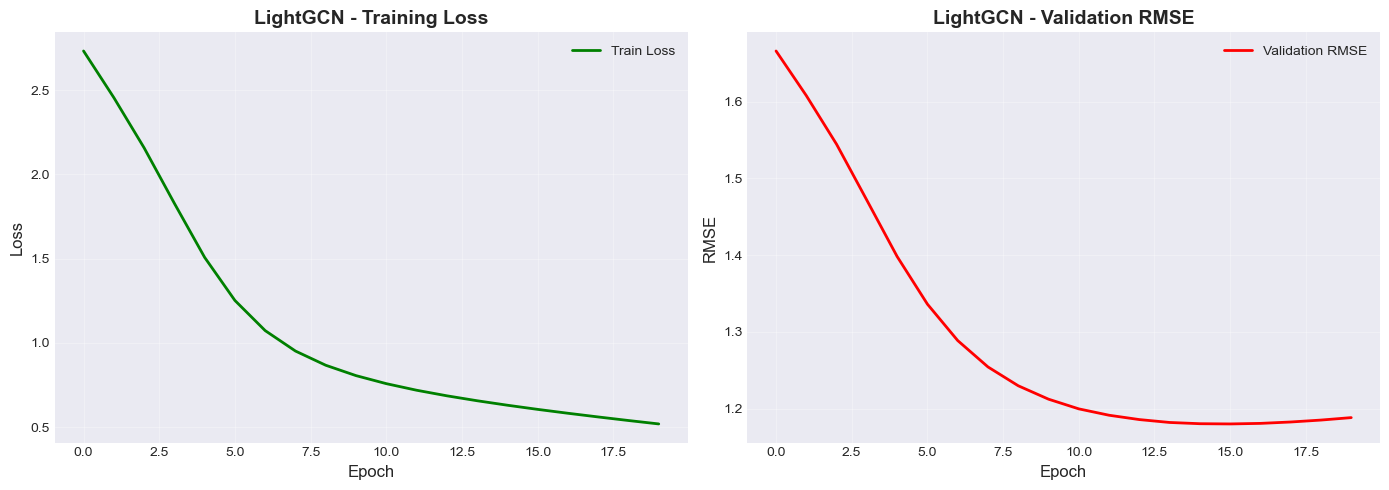

In [34]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses_gcn, label='Train Loss', linewidth=2, color='green')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('LightGCN - Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_rmses_gcn, label='Validation RMSE', color='red', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('LightGCN - Validation RMSE', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 9. Model Comparison and Results

In [35]:
# Compare models
print("=" * 80)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("=" * 80)

results = pd.DataFrame({
    'Model': ['Two Tower MLP', 'LightGCN'],
    'Test RMSE': [test_rmse, test_rmse_gcn],
    'Test MAE': [test_mae, test_mae_gcn]
})

print(results.to_string(index=False))
print("=" * 80)

# Calculate improvement
rmse_improvement = ((test_rmse - test_rmse_gcn) / test_rmse) * 100
mae_improvement = ((test_mae - test_mae_gcn) / test_mae) * 100

print(f"\nLightGCN vs Two Tower MLP:")
print(f"RMSE improvement: {rmse_improvement:+.2f}%")
print(f"MAE improvement: {mae_improvement:+.2f}%")

MODEL COMPARISON - TEST SET PERFORMANCE
        Model  Test RMSE  Test MAE
Two Tower MLP   1.073641  0.817616
     LightGCN   1.209470  1.055426

LightGCN vs Two Tower MLP:
RMSE improvement: -12.65%
MAE improvement: -29.09%


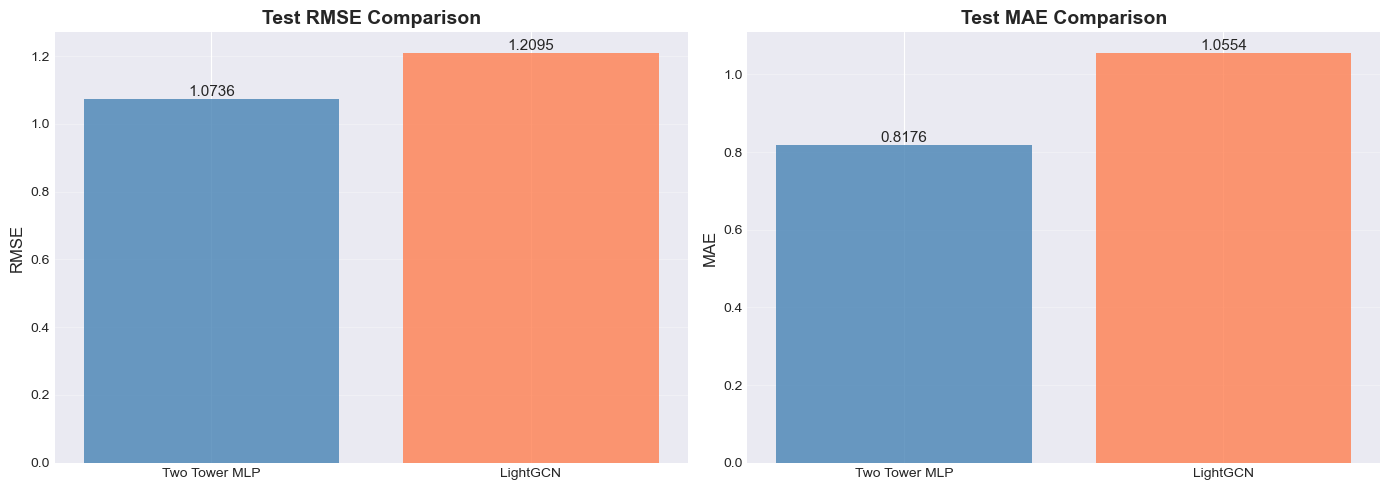

In [36]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Two Tower MLP', 'LightGCN']
rmse_values = [test_rmse, test_rmse_gcn]
mae_values = [test_mae, test_mae_gcn]

# RMSE comparison
bars1 = axes[0].bar(models, rmse_values, color=['steelblue', 'coral'], alpha=0.8)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('Test RMSE Comparison', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=11)

# MAE comparison
bars2 = axes[1].bar(models, mae_values, color=['steelblue', 'coral'], alpha=0.8)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Test MAE Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()